# CDT Morris Network Discovery (Stage 1.5)

## Overview
- **Goal**: Generate Fig 4B and Fig 4D for Stage 1.5 model
- **Model**: CDT-II Stage 1.5 (2,361 genes, val_r=0.5728)
- **Output**: `gfi1b_attn_vs_effect.png`, `gfi1b_attn_vs_gradient.png`

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch: 2.9.0+cu126
CUDA: True
GPU: NVIDIA A100-SXM4-80GB


In [3]:
!pip install h5py tqdm scipy seaborn -q

import os
import h5py
import json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
from tqdm import tqdm
from datetime import datetime
from scipy.stats import pearsonr, hypergeom
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass
from typing import Optional

print("Imports done!")

Imports done!


## Paths (Stage 1.5)

In [4]:
# Stage 1.5 paths
DRIVE_BASE = Path("/content/drive/MyDrive/cdt_data")
MODEL_BASE = Path("/content/drive/MyDrive/cdt_outputs/morris_crispri_stage1_5")
OUTPUT_BASE = Path("/content/drive/MyDrive/cdt_outputs/morris_analysis_stage1_5")
OUTPUT_BASE.mkdir(parents=True, exist_ok=True)

# Stage 1.5 data (2,361 genes)
EFFECTS_PATH = DRIVE_BASE / "morris_celllevel_effects_2361.h5"
TSS_ENFORMER_PATH = DRIVE_BASE / "morris_28genes_enformer.h5"
MODEL_PATH = MODEL_BASE / "cdt_morris_celllevel_best.pt"

# Check files
print("Checking files...")
for name, path in [
    ("Effects (2361)", EFFECTS_PATH),
    ("TSS Enformer", TSS_ENFORMER_PATH),
    ("Model (Stage 1.5)", MODEL_PATH),
]:
    status = "OK" if path.exists() else "NOT FOUND"
    print(f"  [{status}] {name}: {path}")

Checking files...
  [OK] Effects (2361): /content/drive/MyDrive/cdt_data/morris_celllevel_effects_2361.h5
  [OK] TSS Enformer: /content/drive/MyDrive/cdt_data/morris_28genes_enformer.h5
  [OK] Model (Stage 1.5): /content/drive/MyDrive/cdt_outputs/morris_crispri_stage1_5/cdt_morris_celllevel_best.pt


## Load Data

In [5]:
# Load cell-level effects
print("Loading cell-level effects...")
with h5py.File(EFFECTS_PATH, 'r') as f:
    log2fc = f['log2fc'][:]  # [n_cells, 2361]
    cell_expr = f['cell_expr'][:]  # [n_cells, 2361]
    target_gene_idx = f['target_gene_idx'][:]  # [n_cells]
    target_gene_names = [g.decode() if isinstance(g, bytes) else g
                         for g in f['target_gene_names'][:]]
    val_genes = [g.decode() if isinstance(g, bytes) else g
                 for g in f['val_genes'][:]]
    ntc_mean_expr = f['ntc_mean_expr'][:]  # [2361]

    # Try to get gene names
    if 'gene_names_cdt' in f:
        cdt_genes = [g.decode() if isinstance(g, bytes) else g for g in f['gene_names_cdt'][:]]
    else:
        cdt_genes = [f"gene_{i}" for i in range(log2fc.shape[1])]

N_GENES = len(cdt_genes)
gene_to_idx = {g: i for i, g in enumerate(cdt_genes)}

print(f"  Cells: {log2fc.shape[0]}")
print(f"  Genes: {N_GENES}")
print(f"  Val genes: {val_genes}")

Loading cell-level effects...
  Cells: 8250
  Genes: 2361
  Val genes: ['CD44', 'CD52', 'GFI1B', 'TFRC', 'TNFSF9']


In [6]:
# Load Enformer embeddings
print("Loading Enformer embeddings...")
with h5py.File(TSS_ENFORMER_PATH, 'r') as f:
    tss_enformer_emb = f['embeddings'][:]  # [n_genes, 896, 3072]
    tss_enformer_genes = [g.decode() if isinstance(g, bytes) else g
                          for g in f['gene_names'][:]]
tss_gene_to_enformer = {gene: i for i, gene in enumerate(tss_enformer_genes)}

print(f"  Enformer shape: {tss_enformer_emb.shape}")
print(f"  Enformer genes: {tss_enformer_genes}")

Loading Enformer embeddings...
  Enformer shape: (28, 896, 3072)
  Enformer genes: ['CD52', 'CD58', 'FCGR2A', 'CD55', 'ITGB1', 'ENTPD1', 'CD81', 'CD44', 'CD82', 'SLC3A2', 'KLRG1', 'CD69', 'KLRD1', 'TNFSF13B', 'LGALS3', 'B2M', 'IL21R', 'CD19', 'ITGAE', 'TNFSF9', 'ICAM1', 'NECTIN2', 'EPCAM', 'CD40', 'TFRC', 'CD83', 'MSR1', 'GFI1B']


In [7]:
# Build val cell indices
val_cells_by_gene = {}
for gene in val_genes:
    gene_idx_in_target = target_gene_names.index(gene)
    mask = target_gene_idx == gene_idx_in_target
    val_cells_by_gene[gene] = np.where(mask)[0]
    print(f"  {gene}: {len(val_cells_by_gene[gene])} cells")

  CD44: 233 cells
  CD52: 131 cells
  GFI1B: 477 cells
  TFRC: 847 cells
  TNFSF9: 349 cells


## Model Definition (Stage 1.5)

In [8]:
@dataclass
class CDTCRISPRiConfig:
    dna_dim: int = 3072
    dna_seq_len: int = 896
    n_genes: int = 2361  # Stage 1.5
    hidden_dim: int = 512
    nhead: int = 8
    dropout: float = 0.3
    dna_self_attn_layers: int = 2
    rna_self_attn_layers: int = 1


class RawExpressionEncoder(nn.Module):
    def __init__(self, n_genes, hidden_dim, dropout=0.1):
        super().__init__()
        self.n_genes = n_genes
        self.hidden_dim = hidden_dim
        self.gene_embedding = nn.Embedding(n_genes, hidden_dim)
        self.expr_projector = nn.Sequential(
            nn.Linear(1, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU(), nn.Dropout(dropout)
        )
        self.combine = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim), nn.LayerNorm(hidden_dim), nn.Dropout(dropout)
        )

    def forward(self, expression):
        batch_size = expression.size(0)
        device = expression.device
        gene_ids = torch.arange(self.n_genes, device=device)
        gene_emb = self.gene_embedding(gene_ids).unsqueeze(0).expand(batch_size, -1, -1)
        expr_emb = self.expr_projector(expression.unsqueeze(-1))
        combined = torch.cat([gene_emb, expr_emb], dim=-1)
        return self.combine(combined)


class SequenceProjector(nn.Module):
    def __init__(self, input_dim, output_dim, dropout=0.1):
        super().__init__()
        self.linear = nn.Linear(input_dim, output_dim)
        self.norm = nn.LayerNorm(output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.dropout(self.norm(self.linear(x)))


class FlashSelfAttentionBlock(nn.Module):
    def __init__(self, d_model, nhead=8, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.nhead = nhead
        self.head_dim = d_model // nhead
        self.dropout_p = dropout
        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_model * 4), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_model * 4, d_model), nn.Dropout(dropout)
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        batch_size, seq_len, _ = x.shape
        Q = self.q_proj(x).view(batch_size, seq_len, self.nhead, self.head_dim).transpose(1, 2)
        K = self.k_proj(x).view(batch_size, seq_len, self.nhead, self.head_dim).transpose(1, 2)
        V = self.v_proj(x).view(batch_size, seq_len, self.nhead, self.head_dim).transpose(1, 2)
        attn_out = F.scaled_dot_product_attention(Q, K, V, dropout_p=self.dropout_p if self.training else 0.0)
        attn_out = attn_out.transpose(1, 2).contiguous().view(batch_size, seq_len, self.d_model)
        attn_out = self.out_proj(attn_out)
        x = self.norm1(x + self.dropout(attn_out))
        x = self.norm2(x + self.ffn(x))
        return x


class FlashCrossAttentionBlock(nn.Module):
    def __init__(self, d_model, nhead=8, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.nhead = nhead
        self.head_dim = d_model // nhead
        self.dropout_p = dropout
        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_model * 4), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_model * 4, d_model), nn.Dropout(dropout)
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, query, key_value):
        batch_size, query_len, _ = query.shape
        key_len = key_value.shape[1]
        Q = self.q_proj(query).view(batch_size, query_len, self.nhead, self.head_dim).transpose(1, 2)
        K = self.k_proj(key_value).view(batch_size, key_len, self.nhead, self.head_dim).transpose(1, 2)
        V = self.v_proj(key_value).view(batch_size, key_len, self.nhead, self.head_dim).transpose(1, 2)
        attn_out = F.scaled_dot_product_attention(Q, K, V, dropout_p=self.dropout_p if self.training else 0.0)
        attn_out = attn_out.transpose(1, 2).contiguous().view(batch_size, query_len, self.d_model)
        attn_out = self.out_proj(attn_out)
        x = self.norm1(query + self.dropout(attn_out))
        x = self.norm2(x + self.ffn(x))
        return x


class VirtualCellEmbedderDNARNA(nn.Module):
    def __init__(self, d_model, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.nhead = 4
        self.head_dim = d_model // self.nhead
        self.dna_query = nn.Parameter(torch.randn(1, 1, d_model))
        self.rna_query = nn.Parameter(torch.randn(1, 1, d_model))
        self.dna_q_proj = nn.Linear(d_model, d_model)
        self.dna_k_proj = nn.Linear(d_model, d_model)
        self.dna_v_proj = nn.Linear(d_model, d_model)
        self.dna_out_proj = nn.Linear(d_model, d_model)
        self.rna_q_proj = nn.Linear(d_model, d_model)
        self.rna_k_proj = nn.Linear(d_model, d_model)
        self.rna_v_proj = nn.Linear(d_model, d_model)
        self.rna_out_proj = nn.Linear(d_model, d_model)
        self.fusion = nn.Sequential(
            nn.Linear(d_model * 2, d_model * 2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model), nn.LayerNorm(d_model)
        )

    def _attention_pool(self, query, key_value, q_proj, k_proj, v_proj, out_proj):
        batch_size = key_value.size(0)
        seq_len = key_value.size(1)
        query = query.expand(batch_size, -1, -1)
        Q = q_proj(query).view(batch_size, 1, self.nhead, self.head_dim).transpose(1, 2)
        K = k_proj(key_value).view(batch_size, seq_len, self.nhead, self.head_dim).transpose(1, 2)
        V = v_proj(key_value).view(batch_size, seq_len, self.nhead, self.head_dim).transpose(1, 2)
        attn_out = F.scaled_dot_product_attention(Q, K, V)
        attn_out = attn_out.transpose(1, 2).contiguous().view(batch_size, 1, self.d_model)
        return out_proj(attn_out).squeeze(1)

    def forward(self, dna_encoded, rna_encoded):
        dna_pooled = self._attention_pool(
            self.dna_query, dna_encoded,
            self.dna_q_proj, self.dna_k_proj, self.dna_v_proj, self.dna_out_proj
        )
        rna_pooled = self._attention_pool(
            self.rna_query, rna_encoded,
            self.rna_q_proj, self.rna_k_proj, self.rna_v_proj, self.rna_out_proj
        )
        concat = torch.cat([dna_pooled, rna_pooled], dim=-1)
        return self.fusion(concat)


class CDTCRISPRiModel(nn.Module):
    def __init__(self, config=None):
        super().__init__()
        if config is None:
            config = CDTCRISPRiConfig()
        self.config = config
        self.dna_projector = SequenceProjector(config.dna_dim, config.hidden_dim, config.dropout)
        self.dna_self_attn_layers = nn.ModuleList([
            FlashSelfAttentionBlock(config.hidden_dim, config.nhead, config.dropout)
            for _ in range(config.dna_self_attn_layers)
        ])
        self.rna_encoder = RawExpressionEncoder(config.n_genes, config.hidden_dim, config.dropout)
        self.rna_self_attn_layers = nn.ModuleList([
            FlashSelfAttentionBlock(config.hidden_dim, config.nhead, config.dropout)
            for _ in range(config.rna_self_attn_layers)
        ])
        self.dna_to_rna = FlashCrossAttentionBlock(config.hidden_dim, config.nhead, config.dropout)
        self.vce = VirtualCellEmbedderDNARNA(config.hidden_dim, config.dropout)
        self.task_layer = nn.Sequential(
            nn.Linear(config.hidden_dim, config.hidden_dim), nn.GELU(), nn.Dropout(config.dropout),
            nn.Linear(config.hidden_dim, config.n_genes)
        )

    def forward(self, dna_emb, rna_expr):
        dna = self.dna_projector(dna_emb)
        rna = self.rna_encoder(rna_expr)
        for layer in self.dna_self_attn_layers:
            dna = layer(dna)
        for layer in self.rna_self_attn_layers:
            rna = layer(rna)
        rna = self.dna_to_rna(query=rna, key_value=dna)
        cell_embedding = self.vce(dna, rna)
        effect = self.task_layer(cell_embedding)
        return effect

print("Model defined!")

Model defined!


In [9]:
# Load model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

config = CDTCRISPRiConfig()
model = CDTCRISPRiModel(config).to(device)
state_dict = torch.load(MODEL_PATH, map_location=device, weights_only=True)
model.load_state_dict(state_dict)
model.eval()

print(f"Model loaded: {MODEL_PATH}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Device: cuda
Model loaded: /content/drive/MyDrive/cdt_outputs/morris_crispri_stage1_5/cdt_morris_celllevel_best.pt
Parameters: 21,072,185


## Extract GFI1B RNA Self-Attention

In [10]:
# Extract RNA Self-Attention for GFI1B cells
print("Extracting GFI1B RNA Self-Attention...")

gene = 'GFI1B'
cells = val_cells_by_gene[gene]
dna = tss_enformer_emb[tss_gene_to_enformer[gene]]

n_sample = min(20, len(cells))  # Use more cells for stable estimate
rna_self_attns = []

for ci in tqdm(cells[:n_sample], desc="Extracting attention"):
    dna_t = torch.from_numpy(dna.astype(np.float32)).unsqueeze(0).to(device)
    rna_t = torch.from_numpy(cell_expr[ci].astype(np.float32)).unsqueeze(0).to(device)

    with torch.no_grad():
        # Forward through DNA layers
        dna_enc = model.dna_projector(dna_t)
        for layer in model.dna_self_attn_layers:
            dna_enc = layer(dna_enc)

        # RNA encoding
        rna_enc = model.rna_encoder(rna_t)

        # Manual RNA self-attention extraction
        rna_layer = model.rna_self_attn_layers[0]
        batch_size, seq_len, _ = rna_enc.shape
        Q = rna_layer.q_proj(rna_enc).view(batch_size, seq_len, rna_layer.nhead, rna_layer.head_dim).transpose(1, 2)
        K = rna_layer.k_proj(rna_enc).view(batch_size, seq_len, rna_layer.nhead, rna_layer.head_dim).transpose(1, 2)
        scale = rna_layer.head_dim ** -0.5
        attn = torch.matmul(Q, K.transpose(-2, -1)) * scale
        attn = F.softmax(attn, dim=-1)
        rna_self_attns.append(attn[0].cpu().numpy())  # [nhead, n_genes, n_genes]

# Average across cells and heads
rna_self_attn = np.mean(rna_self_attns, axis=0)  # [nhead, n_genes, n_genes]
attn_matrix = rna_self_attn.mean(axis=0)  # [n_genes, n_genes]
np.fill_diagonal(attn_matrix, 0)  # Remove self-loops

print(f"  Attention matrix shape: {attn_matrix.shape}")

Extracting GFI1B RNA Self-Attention...


Extracting attention: 100%|██████████| 20/20 [00:02<00:00,  6.81it/s]


  Attention matrix shape: (2361, 2361)


## Fig 4B: Attention vs Experimental Effect

In [11]:
# GFI1B attention profile (row = what GFI1B attends to)
gfi1b_idx = gene_to_idx.get('GFI1B')

if gfi1b_idx is not None:
    gfi1b_attn_profile = attn_matrix[gfi1b_idx, :]  # [n_genes]
    gfi1b_attn_profile[gfi1b_idx] = 0  # Remove self
else:
    # GFI1B not in gene list, use column (what attends to GFI1B)
    print("GFI1B not in CDT gene list, using attention TO GFI1B")
    # For validation, use mean attention across all genes
    gfi1b_attn_profile = attn_matrix.mean(axis=0)  # [n_genes]

# Experimental effect
gfi1b_gene_idx_in_target = target_gene_names.index('GFI1B')
gfi1b_cell_mask = target_gene_idx == gfi1b_gene_idx_in_target
gfi1b_mean_log2fc = log2fc[gfi1b_cell_mask].mean(axis=0)  # [n_genes]
experimental_effect_abs = np.abs(gfi1b_mean_log2fc)

# Correlation
r_attn_effect, p_attn_effect = pearsonr(gfi1b_attn_profile, experimental_effect_abs)
print(f"Attention vs |Experimental Effect|:")
print(f"  Pearson r = {r_attn_effect:.4f} (p = {p_attn_effect:.2e})")

Attention vs |Experimental Effect|:
  Pearson r = 0.2626 (p = 1.52e-38)


In [12]:
# Enrichment analysis
print("\nTop N Overlap Analysis:")
for n_targets in [50, 100, 200]:
    exp_top = set(np.argsort(experimental_effect_abs)[-n_targets:])
    attn_top = set(np.argsort(gfi1b_attn_profile)[-n_targets:])
    overlap = exp_top & attn_top
    expected = n_targets * n_targets / N_GENES
    enrichment = len(overlap) / expected
    pval = hypergeom.sf(len(overlap) - 1, N_GENES, len(exp_top), len(attn_top))
    print(f"  Top {n_targets}: overlap={len(overlap)}/{n_targets}, enrichment={enrichment:.2f}x, p={pval:.2e}")


Top N Overlap Analysis:
  Top 50: overlap=9/50, enrichment=8.50x, p=5.29e-07
  Top 100: overlap=33/100, enrichment=7.79x, p=6.72e-23
  Top 200: overlap=93/200, enrichment=5.49x, p=2.39e-54


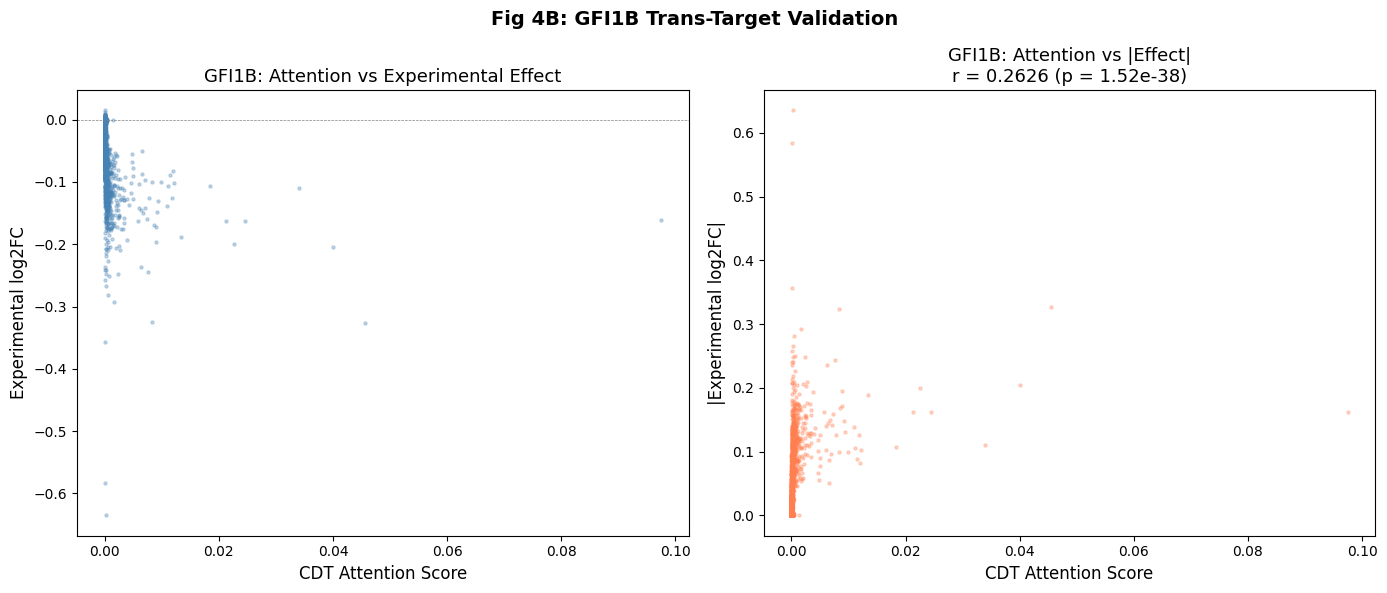


Saved: /content/drive/MyDrive/cdt_outputs/morris_analysis_stage1_5/gfi1b_attn_vs_effect.png


In [13]:
# Fig 4B: Scatter plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Attention vs log2FC (signed)
ax = axes[0]
ax.scatter(gfi1b_attn_profile, gfi1b_mean_log2fc, alpha=0.3, s=5, c='steelblue')
ax.set_xlabel('CDT Attention Score', fontsize=12)
ax.set_ylabel('Experimental log2FC', fontsize=12)
ax.set_title(f'GFI1B: Attention vs Experimental Effect', fontsize=13)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)

# Attention vs |log2FC|
ax = axes[1]
ax.scatter(gfi1b_attn_profile, experimental_effect_abs, alpha=0.3, s=5, c='coral')
ax.set_xlabel('CDT Attention Score', fontsize=12)
ax.set_ylabel('|Experimental log2FC|', fontsize=12)
ax.set_title(f'GFI1B: Attention vs |Effect|\nr = {r_attn_effect:.4f} (p = {p_attn_effect:.2e})', fontsize=13)

plt.suptitle('Fig 4B: GFI1B Trans-Target Validation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_BASE / 'gfi1b_attn_vs_effect.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSaved: {OUTPUT_BASE / 'gfi1b_attn_vs_effect.png'}")

## Fig 4D: Attention vs Gradient

In [14]:
# Gradient-based analysis
print("Computing Gradient-based Attribution...")

# Use GFI1B perturbation context
gene = 'GFI1B'
dna = tss_enformer_emb[tss_gene_to_enformer[gene]]
cell_idx = val_cells_by_gene[gene][0]

dna_t = torch.from_numpy(dna.astype(np.float32)).unsqueeze(0).to(device)
rna_t = torch.from_numpy(cell_expr[cell_idx].astype(np.float32)).unsqueeze(0).to(device)
rna_t.requires_grad_(True)

# Compute gradients for top 50 most affected output genes
top_output_genes = np.argsort(experimental_effect_abs)[-50:]
gradient_map = np.zeros((len(top_output_genes), N_GENES), dtype=np.float32)

for i, out_idx in enumerate(tqdm(top_output_genes, desc="Computing gradients")):
    rna_t.grad = None
    model.zero_grad()
    pred = model(dna_t, rna_t)
    pred[0, out_idx].backward(retain_graph=True)
    gradient_map[i] = rna_t.grad[0].cpu().numpy()

# Mean absolute gradient per input gene
mean_abs_grad = np.abs(gradient_map).mean(axis=0)  # [n_genes]

print(f"\nTop 10 genes by mean |gradient|:")
top_grad_genes = np.argsort(mean_abs_grad)[-10:][::-1]
for idx in top_grad_genes:
    print(f"  {cdt_genes[idx]:<12} |grad|={mean_abs_grad[idx]:.6f}")

Computing Gradient-based Attribution...


Computing gradients: 100%|██████████| 50/50 [00:01<00:00, 45.63it/s]


Top 10 genes by mean |gradient|:
  TXNIP        |grad|=0.051707
  RRM2         |grad|=0.048552
  PTPRC        |grad|=0.046104
  GLUL         |grad|=0.043108
  HMGN2        |grad|=0.042385
  PDE4DIP      |grad|=0.042374
  JUN          |grad|=0.042303
  UBR4         |grad|=0.040885
  AKR1A1       |grad|=0.040093
  FDPS         |grad|=0.039521


In [15]:
# Attention vs Gradient correlation
r_attn_grad, p_attn_grad = pearsonr(gfi1b_attn_profile, mean_abs_grad)

print(f"\nAttention vs Gradient:")
print(f"  Pearson r = {r_attn_grad:.4f} (p = {p_attn_grad:.2e})")

# Top K overlap
print(f"\nTop K Overlap:")
for k in [50, 100, 200]:
    attn_top_k = set(np.argsort(gfi1b_attn_profile)[-k:])
    grad_top_k = set(np.argsort(mean_abs_grad)[-k:])
    overlap = attn_top_k & grad_top_k
    print(f"  Top {k}: overlap={len(overlap)}/{k} ({len(overlap)/k*100:.1f}%)")


Attention vs Gradient:
  Pearson r = 0.2685 (p = 2.83e-40)

Top K Overlap:
  Top 50: overlap=8/50 (16.0%)
  Top 100: overlap=25/100 (25.0%)
  Top 200: overlap=96/200 (48.0%)


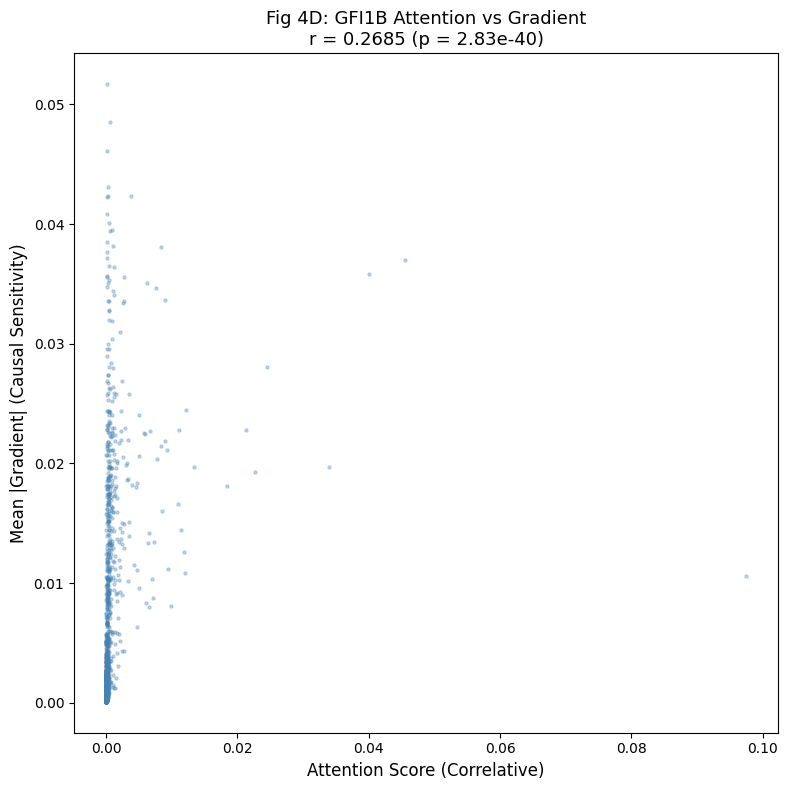


Saved: /content/drive/MyDrive/cdt_outputs/morris_analysis_stage1_5/gfi1b_attn_vs_gradient.png


In [16]:
# Fig 4D: Scatter plot
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(gfi1b_attn_profile, mean_abs_grad, alpha=0.3, s=5, c='steelblue')
ax.set_xlabel('Attention Score (Correlative)', fontsize=12)
ax.set_ylabel('Mean |Gradient| (Causal Sensitivity)', fontsize=12)
ax.set_title(f'Fig 4D: GFI1B Attention vs Gradient\nr = {r_attn_grad:.4f} (p = {p_attn_grad:.2e})', fontsize=13)

plt.tight_layout()
plt.savefig(OUTPUT_BASE / 'gfi1b_attn_vs_gradient.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSaved: {OUTPUT_BASE / 'gfi1b_attn_vs_gradient.png'}")

## Summary

In [17]:
print("=" * 60)
print("NETWORK DISCOVERY SUMMARY (Stage 1.5)")
print("=" * 60)

print(f"\nModel: CDT-II Stage 1.5 (val_r = 0.5728)")
print(f"Genes: {N_GENES}")

print(f"\nFig 4B: Attention vs Experimental Effect")
print(f"  Pearson r = {r_attn_effect:.4f} (p = {p_attn_effect:.2e})")

print(f"\nFig 4D: Attention vs Gradient")
print(f"  Pearson r = {r_attn_grad:.4f} (p = {p_attn_grad:.2e})")

print(f"\nFigures saved to: {OUTPUT_BASE}")
print("  - gfi1b_attn_vs_effect.png (Fig 4B)")
print("  - gfi1b_attn_vs_gradient.png (Fig 4D)")
print("\nDone!")

NETWORK DISCOVERY SUMMARY (Stage 1.5)

Model: CDT-II Stage 1.5 (val_r = 0.5728)
Genes: 2361

Fig 4B: Attention vs Experimental Effect
  Pearson r = 0.2626 (p = 1.52e-38)

Fig 4D: Attention vs Gradient
  Pearson r = 0.2685 (p = 2.83e-40)

Figures saved to: /content/drive/MyDrive/cdt_outputs/morris_analysis_stage1_5
  - gfi1b_attn_vs_effect.png (Fig 4B)
  - gfi1b_attn_vs_gradient.png (Fig 4D)

Done!
